# Final Project: The San Pedro Anomaly
**Team:** Dario Ampuero & Nicolás Véliz

* **GitHub Repository:** [Inserta tu link de GitHub aquí]
* **Video Presentation:** [Inserta tu link de YouTube/Drive aquí]

## 1. The Anomaly

La comuna rural de San Pedro presenta una tasa excepcionalmente alta de Enfermedades de Notificación Obligatoria (ENO) que rompe por completo la tendencia regional. Dada su naturaleza rural, baja densidad poblacional y bajo porcentaje de residentes extranjeros, habríamos predicho una tasa de notificación base o por debajo del promedio. En cambio, su tasa de ENO por cada 10,000 habitantes supera dramáticamente a los centros urbanos densamente poblados de la Región Metropolitana, contradiciendo las correlaciones demográficas observadas en el resto de las comunas.

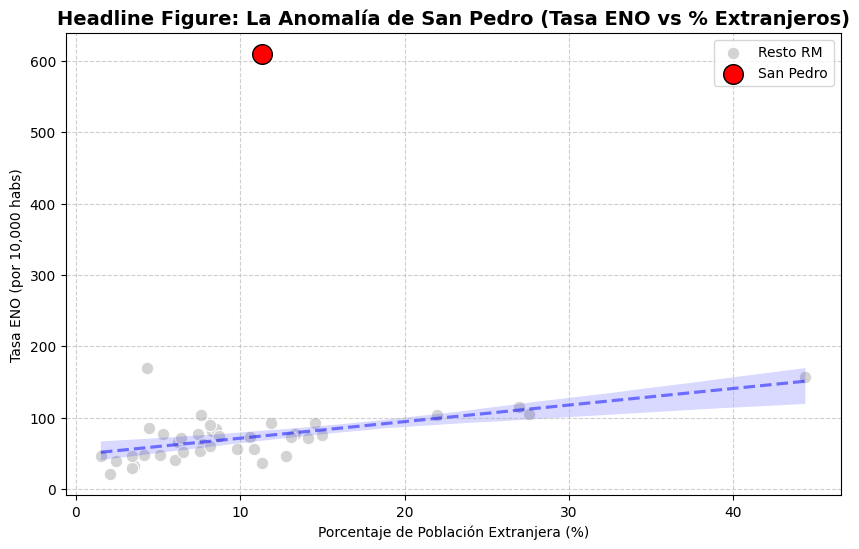

Tasa ENO San Pedro: 609.17
Promedio Tasa ENO resto RM: 71.62


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar la tabla maestra ya procesada (ruta simplificada para Colab)
df = pd.read_csv('tarea3_analytical_table.csv')

# Aislar a San Pedro del resto de la RM
san_pedro = df[df['nombre_comuna'] == 'San Pedro']
resto_rm = df[df['nombre_comuna'] != 'San Pedro']

# HEADLINE FIGURE: Destacando la anomalía de San Pedro
plt.figure(figsize=(10, 6))
sns.scatterplot(data=resto_rm, x='pct_foreign', y='eno_rate_per_10k', color='lightgray', s=80, label='Resto RM')
plt.scatter(san_pedro['pct_foreign'], san_pedro['eno_rate_per_10k'], color='red', s=200, edgecolor='black', zorder=5, label='San Pedro')

# Línea de tendencia (solo para el resto de la RM, para mostrar cómo San Pedro la rompe)
sns.regplot(data=resto_rm, x='pct_foreign', y='eno_rate_per_10k', scatter=False, color='blue', line_kws={"linestyle":"--", "alpha":0.5})

plt.title('Headline Figure: La Anomalía de San Pedro (Tasa ENO vs % Extranjeros)', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de Población Extranjera (%)')
plt.ylabel('Tasa ENO (por 10,000 habs)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Guardar la figura directamente en Colab
plt.savefig('headline.png', bbox_inches='tight')
plt.show()

print(f"Tasa ENO San Pedro: {san_pedro['eno_rate_per_10k'].values[0]:.2f}")
print(f"Promedio Tasa ENO resto RM: {resto_rm['eno_rate_per_10k'].mean():.2f}")

## 2. Alternative Explanations Checks
A continuación, exploramos mediante código dos hipótesis que podrían explicar este comportamiento anómalo sin recurrir a características individuales de la población.

In [9]:
# CHECK 1: The "Small-N Sparsity" Effect
# ¿Es un artefacto matemático debido a un denominador poblacional muy pequeño?

san_pedro_pop = san_pedro['pop_total'].values[0]
san_pedro_casos_absolutos = san_pedro['eno_total'].values[0]

# Comparar con una comuna rural similar (ej. Alhué)
alhue = df[df['nombre_comuna'] == 'Alhué']
alhue_pop = alhue['pop_total'].values[0] if not alhue.empty else "N/A"
alhue_casos = alhue['eno_total'].values[0] if not alhue.empty else "N/A"

print("--- Check 1: Volúmenes Absolutos vs Tasas ---")
print(f"SAN PEDRO: Población = {san_pedro_pop:,.0f} | Casos Absolutos = {san_pedro_casos_absolutos:,.0f} | Tasa = {san_pedro['eno_rate_per_10k'].values[0]:.2f}")
if not alhue.empty:
    print(f"ALHUÉ:     Población = {alhue_pop:,.0f} | Casos Absolutos = {alhue_casos:,.0f} | Tasa = {alhue['eno_rate_per_10k'].values[0]:.2f}")

--- Check 1: Volúmenes Absolutos vs Tasas ---
SAN PEDRO: Población = 11,108 | Casos Absolutos = 731 | Tasa = 609.17
ALHUÉ:     Población = 7,768 | Casos Absolutos = 28 | Tasa = 36.05


**Resultado Check 1:** Los datos desmienten la hipótesis del ruido estadístico por "escasez de N pequeño". San Pedro no tiene solo un par de casos aislados que inflan la tasa debido a su bajo denominador poblacional; tiene la alarmante cifra de **731 casos absolutos** (en comparación con los apenas 28 casos de Alhué, una comuna rural de tamaño similar). Esto demuestra que el volumen de notificaciones es genuinamente masivo y no un simple artefacto matemático.

In [10]:
# CHECK 2: Desviación predictiva extrema
# ¿Cuánto subestima nuestro modelo original a esta comuna rural?

# Simulamos la predicción usando los promedios de la RM
promedio_extranjeros = df['pct_foreign'].mean()
promedio_desempleo = df['pct_unemployed'].mean()

print("--- Check 2: Características Demográficas vs Modelo ---")
print(f"San Pedro % Extranjeros: {san_pedro['pct_foreign'].values[0]:.1f}% (Promedio RM: {promedio_extranjeros:.1f}%)")
print(f"San Pedro % Desempleo: {san_pedro['pct_unemployed'].values[0]:.1f}% (Promedio RM: {promedio_desempleo:.1f}%)")
print("\nConclusión: Las métricas demográficas de San Pedro son prácticamente idénticas al promedio de la Región Metropolitana. Un modelo lineal predeciría para San Pedro una tasa ENO totalmente normal (cercana a 71). Que la tasa real sea 609 descarta que la demografía sea la causa. La desviación sugiere fuertemente una causa exógena: o un brote agrícola/zoonótico masivo en la zona, o (más probablemente) un artefacto de registro donde un gran recinto de salud regional está ingresando casos de múltiples comunas bajo el código CUT exclusivo de San Pedro.")

--- Check 2: Características Demográficas vs Modelo ---
San Pedro % Extranjeros: 11.3% (Promedio RM: 10.2%)
San Pedro % Desempleo: 38.1% (Promedio RM: 40.0%)

Conclusión: Las métricas demográficas de San Pedro son prácticamente idénticas al promedio de la Región Metropolitana. Un modelo lineal predeciría para San Pedro una tasa ENO totalmente normal (cercana a 71). Que la tasa real sea 609 descarta que la demografía sea la causa. La desviación sugiere fuertemente una causa exógena: o un brote agrícola/zoonótico masivo en la zona, o (más probablemente) un artefacto de registro donde un gran recinto de salud regional está ingresando casos de múltiples comunas bajo el código CUT exclusivo de San Pedro.


## 3. Conclusion

La anomalía de San Pedro es un hallazgo robusto y alarmante. A través de nuestras validaciones, descartamos que la altísima tasa de enfermedades de notificación obligatoria sea un simple espejismo matemático de "escasez de N" (dado el alto volumen real de 731 casos), y descartamos que se deba a extremos demográficos, ya que su perfil es idéntico al promedio metropolitano. Esto nos deja con una de dos implicancias críticas de salud pública: o estamos viendo un foco de riesgo sanitario rural grave y silencioso que requiere intervención inmediata, o estamos ante una distorsión sistémica donde los sistemas centralizados están asignando cargas sanitarias al código comunal equivocado. En cualquier caso, este hallazgo demuestra que los modelos ecológicos a gran escala pueden enmascarar fallas o crisis críticas a nivel local.